In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import sys
from pathlib import Path

root = Path.cwd().parent.parent
if str(root) not in sys.path:
    sys.path.append(str(root))

In [ ]:
from src import config
from feature_extraction import extract_mel_spectrogram

In [14]:
import librosa, matplotlib.pyplot as plt

In [15]:
RAW_AUDIO_DIR_EN = Path("../../data/audio/en_clips")
RAW_AUDIO_DIR_BN = Path("../../data/audio/bn_clips")

In [16]:
en_audio_path = RAW_AUDIO_DIR_EN / "A001_clip_6.wav"
bn_audio_path = RAW_AUDIO_DIR_BN / "1_7.wav"

In [17]:
y_en, sr = librosa.load(en_audio_path, sr=config.SAMPLE_RATE)
y_bn, sr = librosa.load(bn_audio_path, sr=config.SAMPLE_RATE)

In [18]:
en_y_spec = extract_mel_spectrogram(audio_path=en_audio_path)
bn_y_spec = extract_mel_spectrogram(audio_path=bn_audio_path)

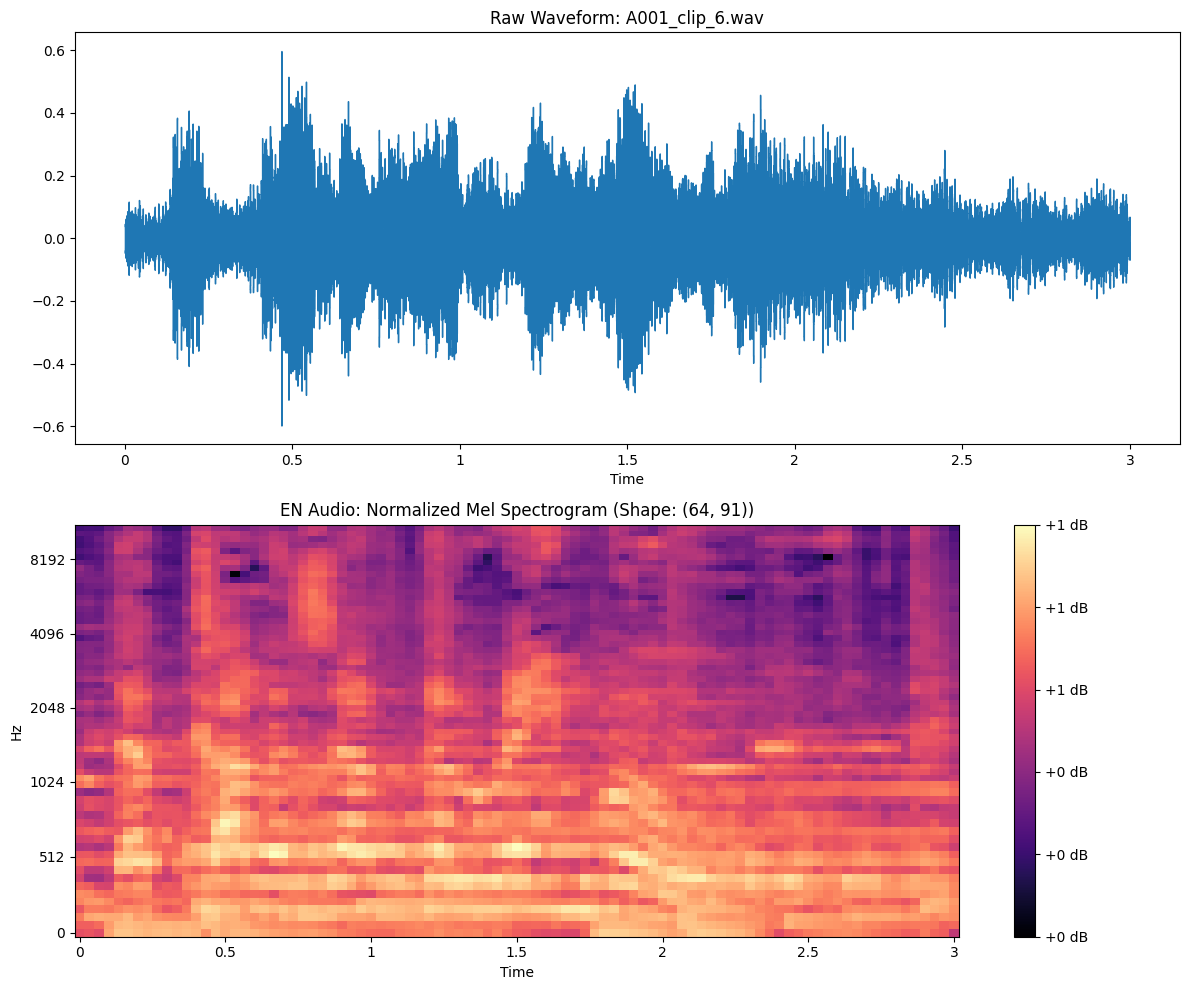

In [19]:
# EN
fig, ax = plt.subplots(2, 1, figsize=(12, 10))

librosa.display.waveshow(y_en, sr=sr, ax=ax[0])
ax[0].set_title(f"Raw Waveform: {en_audio_path.name}")

img = librosa.display.specshow(
    en_y_spec, 
    sr=config.SAMPLE_RATE, 
    hop_length=config.HOP_LENGTH, 
    x_axis='time', 
    y_axis='mel', 
    ax=ax[1]
)
plt.colorbar(img, ax=ax[1], format='%+2.0f dB')
ax[1].set_title(f"EN Audio: Normalized Mel Spectrogram (Shape: {en_y_spec.shape})")

plt.tight_layout()
plt.show()

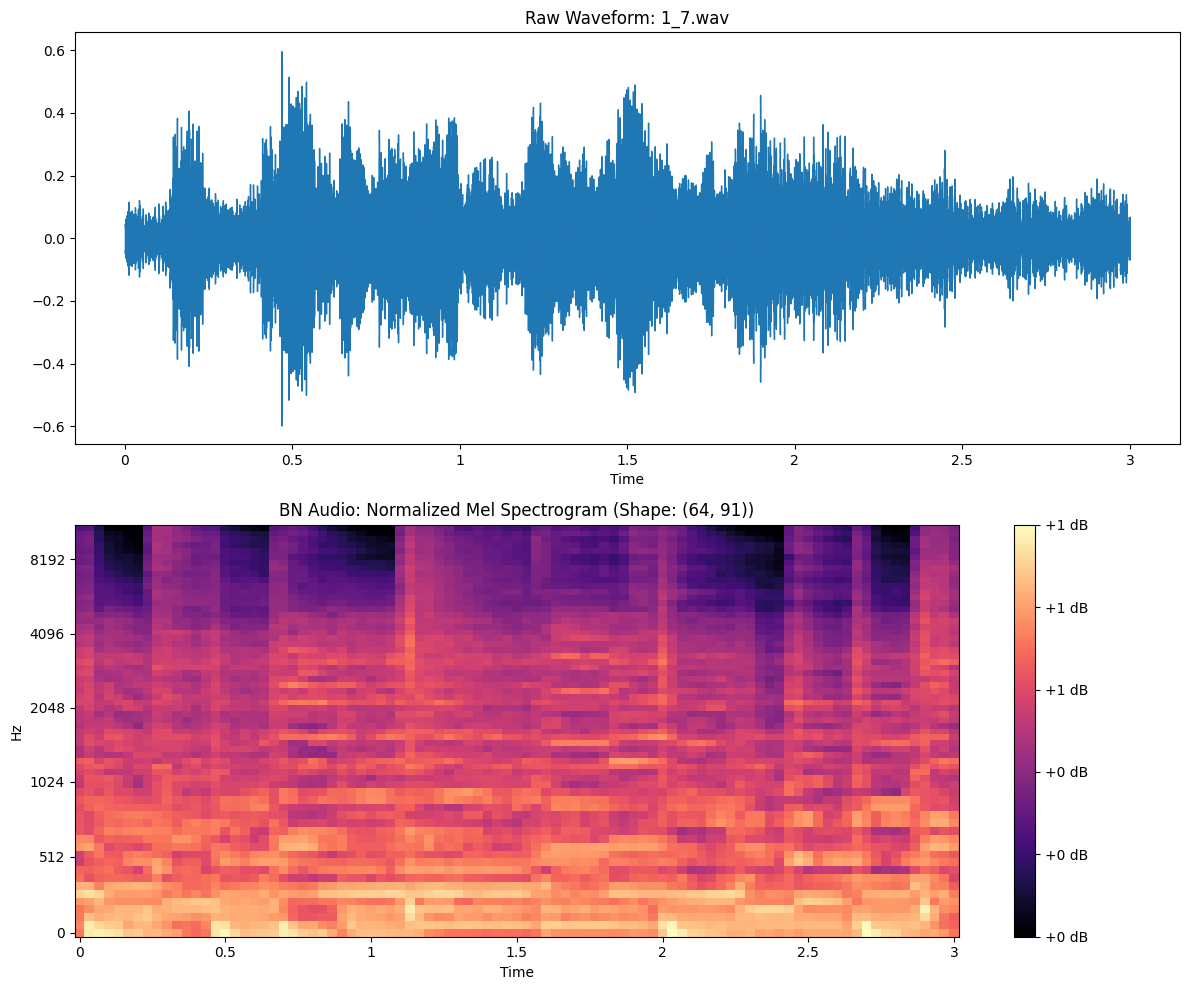

In [20]:
# BN
fig, ax = plt.subplots(2, 1, figsize=(12, 10))

librosa.display.waveshow(y_en, sr=sr, ax=ax[0])
ax[0].set_title(f"Raw Waveform: {bn_audio_path.name}")

img = librosa.display.specshow(
    bn_y_spec, 
    sr=config.SAMPLE_RATE, 
    hop_length=config.HOP_LENGTH, 
    x_axis='time', 
    y_axis='mel', 
    ax=ax[1]
)
plt.colorbar(img, ax=ax[1], format='%+2.0f dB')
ax[1].set_title(f"BN Audio: Normalized Mel Spectrogram (Shape: {bn_y_spec.shape})")

plt.tight_layout()
plt.show()